**RVO Hybrid Heatpumps**

## Introduction - Data Preperation

This is the first notebook you should run when you start the analysis. 

In this notebook we load the datasets, rename and select the relevant columns for our analysis.

Before you run the notebooks, make sure of the following: 
- Ensure you have read the README.md
- Ensure the packages from requirements.txt are installed. These should have been automatically installed when you started the docker container. Otherwise, the code cell below will likely return an error. 
- Ensure you have added the 7 `.csv` files to the `/input/` folder. You should have the following 
`boiler.csv`, `dsmr.csv`, `heatpump.csv`, `household.csv`, `kamstrup.csv`, `knmi.csv`, `room.csv`. The `metadata.csv` is not required for the analysis but provides extra information for all columns, such as their description, unit and any other details to keep in mind. It's recommended to read through this atleast once to better understand the data. 

With that out of the way, you can start with the analysis. Everything should work out of the box and require no configuration other than the steps listed above. It might help to atleast be familiar with the following Python packages to better understand the code: 
- [Pandas](https://pandas.pydata.org/): for manipulating data. 
- [Matplotlib](https://matplotlib.org/): for generating graphs. 

Each notebook will save it's output to the `cache` folder. After running this notebook, you should have a folder called `cache/step1` which contains multiple `.parquet` files. Each `.parquet` file corresponds to a Pandas dataframe, which holds the data we will use in the next step of the analysis. 

Each notebook builds on top of the data exported by the previous notebook. You have to run all the notebooks in order. So only after successfully running notebook `1`, you run notebook `2_data_cleaning.ipynb`.

Side note: you can use notebook `10_run_all.ipynb` to run all notebooks sequentually. This is only recommended if you are familiar with Jupyter notebooks, since it makes errors harder to debug due to you not directly seeing which code cell crashed. This is an alternative to running each notebook manually. 

In [1]:
import pandas as pd
import numpy as np

from datetime import datetime, timedelta

import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sortedcollections import OrderedSet
from pathlib import Path

# if this does not throw an error, you likely have all the correct packages installed. 

Matplotlib is building the font cache; this may take a moment.


# Loading the data

In [3]:
df_household = pd.read_csv("input/household.csv")
df_boiler = pd.read_csv("input/boiler.csv") 
df_dsmr = pd.read_csv("input/dsmr.csv")
df_heatpump = pd.read_csv("input/heatpump.csv")
df_kamstrup = pd.read_csv("input/kamstrup.csv") # kamstrup sensors measures energy delivered by measuring system water temperatures + flow 
df_knmi = pd.read_csv("input/knmi.csv") # de bilt weather temperatures 
df_room = pd.read_csv("input/room.csv")  # inside room temperatures 

# Total Gas Consumption

The gas sensor from the 'slimme meter' (smart meter / DSMR) is an accumulating sensor that should only increase. Note this is the total gas consumption for the enitre house, so it includes things like cooking and showering, instead of only heating. The unit is $m^3$.

Per participant, for their total gas consumption we select the first sensor value per day. Since we will not be looking at what happens hour to hour, but only day to day. 

In [4]:
df_gas_total = df_dsmr[["timestamp", "location_id", "v_gas_consumed"]].rename(
    columns={"timestamp": "time", "location_id": "participant_id", "v_gas_consumed": "gas_total"}
).copy()

df_gas_total["time"] = pd.to_datetime(df_gas_total["time"])

# take the first value per day, since we are not going to look at gas consumption per hour anyways
df_gas_total = df_gas_total.groupby(
    ["participant_id", pd.Grouper(key="time", freq="D")]
).first().reset_index()
df_gas_total

,participant_id,time,gas_total
0,-B51sQOp,2022-06-14,5059.199
1,-B51sQOp,2022-11-08,5015.722
2,-B51sQOp,2022-11-09,5016.573
3,-B51sQOp,2022-11-10,5017.609
4,-B51sQOp,2022-11-11,5017.790
...,...,...,...
86497,zskLB4tU,2024-05-19,8797.667
86498,zskLB4tU,2024-05-20,8797.783
86499,zskLB4tU,2024-05-21,8797.903
86500,zskLB4tU,2024-05-22,8798.025


## Daily Gas Consumption 

From the total gas consumption value per day, we can derive the change per day. This of course gives the gas consumption per day.

In [5]:
df_gas = df_gas_total.copy()

min_date = df_gas["time"].min()
max_date = df_gas["time"].max()

# Create a list to store the reindexed DataFrames
reindexed_data = []

# Resample each id group to ensure all days are included
for id, group in df_gas.groupby("participant_id"):
    # Reindex the group to include all dates between the min and max date
    group = group.set_index("time").reindex(
        pd.date_range(start=min_date, end=max_date, freq="D")
    )
    group["participant_id"] = id  # Re-add the id column
    reindexed_data.append(group)

# Concatenate the reindexed DataFrames back together
complete_daily_consumption = (
    pd.concat(reindexed_data).reset_index().rename(columns={"index": "time"})
)

# Calculate the daily difference in gas total consumption
complete_daily_consumption["consumption_change"] = complete_daily_consumption.groupby(
    "participant_id"
)["gas_total"].diff()

df_gas = complete_daily_consumption
df_gas = df_gas[df_gas['consumption_change'].notna()]
df_gas = df_gas.drop(columns=["gas_total"])
df_gas = df_gas.rename(columns={'consumption_change': 'gas_consumption'})
df_gas

,time,participant_id,gas_consumption
303,2022-11-09,-B51sQOp,0.851
304,2022-11-10,-B51sQOp,1.036
305,2022-11-11,-B51sQOp,0.181
306,2022-11-12,-B51sQOp,1.327
307,2022-11-13,-B51sQOp,0.354
...,...,...,...
151889,2024-05-19,zskLB4tU,0.231
151890,2024-05-20,zskLB4tU,0.116
151891,2024-05-21,zskLB4tU,0.120
151892,2024-05-22,zskLB4tU,0.122


# Total Elektricity Consumption 

This is an accumulating value tracking the total elektricity consumption of the heatpump (in kWh).

In [6]:
df_elek_total = (
    df_heatpump[["timestamp", "location_id", "energy"]]
    .rename(
        columns={
            "timestamp": "time",
            "location_id": "participant_id",
            "energy": "electricity_total",
        }
    )
    .copy()
)
df_elek_total["time"] = pd.to_datetime(df_elek_total["time"])

# take the first value per day, since we are not going to look at gas consumption per hour anyways
df_elek_total = (
    df_elek_total.groupby(["participant_id", pd.Grouper(key="time", freq="D")])
    .first()
    .reset_index()
)
df_elek_total

,participant_id,time,electricity_total
0,-B51sQOp,2022-06-14,0.000
1,-B51sQOp,2022-11-08,0.000
2,-B51sQOp,2022-11-09,0.327
3,-B51sQOp,2022-11-10,0.957
4,-B51sQOp,2022-11-11,1.618
...,...,...,...
92244,zskLB4tU,2024-05-19,1369.180
92245,zskLB4tU,2024-05-20,1369.406
92246,zskLB4tU,2024-05-21,1369.631
92247,zskLB4tU,2024-05-22,1369.859


In [7]:
df_elek = df_elek_total.copy()

min_date = df_elek["time"].min()
max_date = df_elek["time"].max()

# Create a list to store the reindexed DataFrames
reindexed_data = []

# Resample each id group to ensure all days are included
for id, group in df_elek.groupby("participant_id"):
    # Reindex the group to include all dates between the min and max date
    group = group.set_index("time").reindex(
        pd.date_range(start=min_date, end=max_date, freq="D")
    )
    group["participant_id"] = id  # Re-add the id column
    reindexed_data.append(group)

# Concatenate the reindexed DataFrames back together
complete_daily_consumption = (
    pd.concat(reindexed_data).reset_index().rename(columns={"index": "time"})
)

# Calculate the daily difference in gas total consumption
complete_daily_consumption["day_to_day_change"] = complete_daily_consumption.groupby(
    "participant_id"
)["electricity_total"].diff()

df_elek = complete_daily_consumption
df_elek = df_elek[df_elek["day_to_day_change"].notna()]
df_elek = df_elek.drop(columns=["electricity_total"])
df_elek = df_elek.rename(columns={"day_to_day_change": "elek_consumption"})
df_elek

,time,participant_id,elek_consumption
303,2022-11-09,-B51sQOp,0.327
304,2022-11-10,-B51sQOp,0.630
305,2022-11-11,-B51sQOp,0.661
306,2022-11-12,-B51sQOp,0.660
307,2022-11-13,-B51sQOp,0.679
...,...,...,...
151889,2024-05-19,zskLB4tU,0.226
151890,2024-05-20,zskLB4tU,0.226
151891,2024-05-21,zskLB4tU,0.225
151892,2024-05-22,zskLB4tU,0.228


# System / Hybride heat pump

## Heatmpump flowrate

`f_system` is the instananious flowarate (L/h), meaning the flowrate at the moment of measurement, of the water through the heatpump. Take per participant, the average flowrate per day and call it `flowrate`. 

In [8]:
df_flow = (
    df_kamstrup[["timestamp", "location_id", "f_system"]]
    .copy()
    .rename(
        columns={
            "timestamp": "time",
            "location_id": "participant_id",
            "f_system": "flowrate",
        }
    )
)

df_flow["time"] = pd.to_datetime(df_flow["time"])  # convert string to datetime column

df_flow = df_flow.groupby(
    ["participant_id", pd.Grouper(key="time", freq="D")]
).mean().reset_index()
df_flow

,participant_id,time,flowrate
0,-B51sQOp,2022-06-14,0.000000
1,-B51sQOp,2022-11-08,323.411765
2,-B51sQOp,2022-11-09,347.645833
3,-B51sQOp,2022-11-10,436.173913
4,-B51sQOp,2022-11-11,467.770833
...,...,...,...
92245,zskLB4tU,2024-05-19,0.000000
92246,zskLB4tU,2024-05-20,0.000000
92247,zskLB4tU,2024-05-21,13.531250
92248,zskLB4tU,2024-05-22,0.000000


## System Heat - Total

The 'heat' displaced/delivered by the system (combination of boiler and heatpump) to the house. In other words, it is derived from the difference between supply and return water temperature. Default unit is GigaJoule, for convience convert it to kWh. 

Note, sometimes in the summer a brief large spike can appear. This happens less often in the published data set due to the lower resolution of data. As such, `extra_analyses` folder contains an example image `example_of_pump_cycle_in_summer.jpg` to illustrate this. It turns out, most heat pumps cycle the pump in the summer. 

This happens e to the possibility of the still water in the system being heated differntly at the input and output side, once the pump activates, it might detect a brief temperatur difference which causes the sensors to think that heat is being supplied to the house. This is again, due to the fact that a minute temperature difference has been created by the still water in the system heating up more on one side (supply or return) than the other.

In [9]:
df_energy_out_total = (
    df_kamstrup[["timestamp", "location_id", "e_thermal_system"]]
    .copy()
    .rename(
        columns={
            "timestamp": "time",
            "location_id": "participant_id",
            "e_thermal_system": "energy_out_total",
        }
    )
)

df_energy_out_total["time"] = pd.to_datetime(
    df_energy_out_total["time"]
)  # convert string to datetime column

df_energy_out_total = (
    df_energy_out_total.groupby(["participant_id", pd.Grouper(key="time", freq="D")])
    .mean()
    .reset_index()
)
df_energy_out_total["energy_out_total"] = (
    df_energy_out_total["energy_out_total"] / 0.0036
)  # convert GJ to kWh
df_energy_out_total

,participant_id,time,energy_out_total
0,-B51sQOp,2022-06-14,0.000000
1,-B51sQOp,2022-11-08,5.969499
2,-B51sQOp,2022-11-09,28.538773
3,-B51sQOp,2022-11-10,67.315821
4,-B51sQOp,2022-11-11,109.126157
...,...,...,...
92245,zskLB4tU,2024-05-19,11986.666667
92246,zskLB4tU,2024-05-20,11986.666667
92247,zskLB4tU,2024-05-21,11986.666667
92248,zskLB4tU,2024-05-22,11986.666667


## System Heat - Daily (Energy out)

The 'heat' displaced/delivered by the system (combination of boiler and heatpump) to the house. In other words, it is derived from the difference between supply and return water temperature. Default unit is GigaJoule, for convience gets converted to kWh. <br>

In [10]:
df_energy_out = df_energy_out_total.copy()

min_date = df_energy_out["time"].min()
max_date = df_energy_out["time"].max()

# Create a list to store the reindexed DataFrames
reindexed_data = []

# Resample each id group to ensure all days are included
for id, group in df_energy_out.groupby("participant_id"):
    # Reindex the group to include all dates between the min and max date
    group = group.set_index("time").reindex(
        pd.date_range(start=min_date, end=max_date, freq="D")
    )
    group["participant_id"] = id  # Re-add the id column
    reindexed_data.append(group)

# Concatenate the reindexed DataFrames back together
all_days_per_participant = (
    pd.concat(reindexed_data).reset_index().rename(columns={"index": "time"})
)

# Calculate the daily difference in gas total consumption
all_days_per_participant["day_to_day_change"] = all_days_per_participant.groupby(
    "participant_id"
)["energy_out_total"].diff()

df_energy_out = all_days_per_participant
df_energy_out = df_energy_out[df_energy_out["day_to_day_change"].notna()]
df_energy_out = df_energy_out.drop(columns=["energy_out_total"])
df_energy_out = df_energy_out.rename(columns={"day_to_day_change": "energy_out"})
df_energy_out["energy_out"] = df_energy_out["energy_out"].round(2) # round out any floatingpoint precision errors
df_energy_out

,time,participant_id,energy_out
303,2022-11-09,-B51sQOp,22.57
304,2022-11-10,-B51sQOp,38.78
305,2022-11-11,-B51sQOp,41.81
306,2022-11-12,-B51sQOp,54.44
307,2022-11-13,-B51sQOp,58.67
...,...,...,...
151889,2024-05-19,zskLB4tU,0.00
151890,2024-05-20,zskLB4tU,0.00
151891,2024-05-21,zskLB4tU,0.00
151892,2024-05-22,zskLB4tU,0.00


## Heatmpump supply temperature

The temperature (in Celcius) of the water entering the house / leaving the heatpump at a specific moment in time. When the heatpump is active, this is the hot water side, meaning the water used to heat the house. 

In [11]:
df_supply_temp = (
    df_kamstrup[["timestamp", "location_id", "t_supply"]]
    .copy()
    .rename(
        columns={
            "timestamp": "time",
            "location_id": "participant_id",
            "t_supply": "supply_temp",
        }
    )
)

df_supply_temp["time"] = pd.to_datetime(
    df_supply_temp["time"]
)  # convert string to datetime column

df_supply_temp = (
    df_supply_temp.groupby(["participant_id", pd.Grouper(key="time", freq="D")])
    .mean()
    .reset_index()
)
df_supply_temp

,participant_id,time,supply_temp
0,-B51sQOp,2022-06-14,24.275000
1,-B51sQOp,2022-11-08,23.271373
2,-B51sQOp,2022-11-09,23.764792
3,-B51sQOp,2022-11-10,25.558261
4,-B51sQOp,2022-11-11,26.121146
...,...,...,...
92245,zskLB4tU,2024-05-19,21.753438
92246,zskLB4tU,2024-05-20,20.976458
92247,zskLB4tU,2024-05-21,20.980521
92248,zskLB4tU,2024-05-22,20.614479


## Heatmpump supply temperature, if active

For analysis of supply temperature, we are really only interested in the temperatures if the heat pump is actively heating the house. As such, we filter on  moments "energy_out" > 0.5, meaning currently atleast 500Wh (0.5kWh) is being supplied by the heat pump. 

In [12]:
df_supply_temp_active = (
    df_kamstrup[["timestamp", "location_id", "t_supply", "p_thermal_system"]]
    .copy()
    .rename(
        columns={
            "timestamp": "time",
            "location_id": "participant_id",
            "t_supply": "supply_temp_active",
            "p_thermal_system": "energy_out",
        }
    )
)
df_supply_temp_active["time"] = pd.to_datetime(df_supply_temp_active["time"])

# Each value is the first value in a 15 minute interval. This line can be used to thus round it down to the nearest interval
# df_supply_temp_active["time"] = df_supply_temp_active["time"].dt.floor("15min")
df_supply_temp_active = df_supply_temp_active[df_supply_temp_active["energy_out"] > 0.5]

# mean supply per parcipant / day if active
df_supply_temp_active = (
    df_supply_temp_active.groupby(["participant_id", pd.Grouper(key="time", freq="D")])
    .mean()
    .reset_index()
)
df_supply_temp_active = df_supply_temp_active.drop(columns=["energy_out"])
df_supply_temp_active

,participant_id,time,supply_temp_active
0,-B51sQOp,2022-11-08,29.170000
1,-B51sQOp,2022-11-09,29.757273
2,-B51sQOp,2022-11-10,29.668158
3,-B51sQOp,2022-11-11,29.745000
4,-B51sQOp,2022-11-12,30.070923
...,...,...,...
62191,zskLB4tU,2024-05-07,33.291538
62192,zskLB4tU,2024-05-08,39.597931
62193,zskLB4tU,2024-05-09,42.020690
62194,zskLB4tU,2024-05-10,36.582857


## Heatpump return temperature 

The temperature of the water returning after circulating through the house. Colder than supply temperature. Except in the summer, when the heatpump is off and the house might actually heat up the water.

In [13]:
df_return_temp = (
    df_kamstrup[["timestamp", "location_id", "t_return"]]
    .copy()
    .rename(
        columns={
            "timestamp": "time",
            "location_id": "participant_id",
            "t_return": "return_temp",
        }
    )
)

df_return_temp["time"] = pd.to_datetime(
    df_return_temp["time"]
)  # convert string to datetime column

df_return_temp = (
    df_return_temp.groupby(["participant_id", pd.Grouper(key="time", freq="D")])
    .mean()
    .reset_index()
)
df_return_temp

,participant_id,time,return_temp
0,-B51sQOp,2022-06-14,24.435000
1,-B51sQOp,2022-11-08,21.981176
2,-B51sQOp,2022-11-09,22.422500
3,-B51sQOp,2022-11-10,23.516413
4,-B51sQOp,2022-11-11,23.973437
...,...,...,...
92245,zskLB4tU,2024-05-19,22.232083
92246,zskLB4tU,2024-05-20,21.502708
92247,zskLB4tU,2024-05-21,21.179271
92248,zskLB4tU,2024-05-22,20.971667


## Heatpump return temperature, if active

Similar to supply temperature, calculate average return temperature (Celcius) if heat pump is active.

In [14]:
df_return_temp_active = (
    df_kamstrup[["timestamp", "location_id", "t_return", "p_thermal_system"]]
    .copy()
    .rename(
        columns={
            "timestamp": "time",
            "location_id": "participant_id",
            "t_return": "return_temp_active",
            "p_thermal_system": "energy_out",
        }
    )
)
df_return_temp_active["time"] = pd.to_datetime(df_return_temp_active["time"])

# Each value is the first value in a 15 minute interval. This line of code can be used to thus round it down to the nearest interval
# df_return_temp_active["time"] = df_return_temp_active["time"].dt.floor("15min")
df_return_temp_active = df_return_temp_active[df_return_temp_active["energy_out"] > 0.5]

# mean supply per parcipant / day if active
df_return_temp_active = (
    df_return_temp_active.groupby(["participant_id", pd.Grouper(key="time", freq="D")])
    .mean()
    .reset_index()
)
df_return_temp_active = df_return_temp_active.drop(columns=["energy_out"])
df_return_temp_active

,participant_id,time,return_temp_active
0,-B51sQOp,2022-11-08,23.640000
1,-B51sQOp,2022-11-09,24.083182
2,-B51sQOp,2022-11-10,24.814211
3,-B51sQOp,2022-11-11,25.128636
4,-B51sQOp,2022-11-12,25.894154
...,...,...,...
62191,zskLB4tU,2024-05-07,31.110769
62192,zskLB4tU,2024-05-08,37.219655
62193,zskLB4tU,2024-05-09,39.785172
62194,zskLB4tU,2024-05-10,34.407143


# KNMI - Outside temperature

`knmi.csv` contains data per participant for the nearest knmi weather station. 

`T` is the outside temperature from the nearest KNMI weather station (in 0.1 Celcius). From this, take the mean outside temperature per day, per participant, called `outside_temp`.

In [15]:
# In our analysis, we only use the temperature of the nearest knmi station
df_knmi["outside_temp"] = df_knmi["T"] / 10 # divide by 10 since the unit by default is 0.1 Celcius 
df_outside_temp = df_knmi[["timestamp", "location_id", "outside_temp"]].rename(
    columns={"timestamp": "time", "location_id": "participant_id"}
)
df_outside_temp["time"] = pd.to_datetime(
    df_outside_temp["time"]
)  # convert string to datetime column

df_outside_temp = df_outside_temp.groupby(
    ["participant_id", pd.Grouper(key="time", freq="D")]
).mean().reset_index()
df_outside_temp

,participant_id,time,outside_temp
0,-B51sQOp,2022-11-08,13.700000
1,-B51sQOp,2022-11-09,12.954167
2,-B51sQOp,2022-11-10,10.854167
3,-B51sQOp,2022-11-11,9.520833
4,-B51sQOp,2022-11-12,7.616667
...,...,...,...
103796,zskLB4tU,2024-05-11,17.058333
103797,zskLB4tU,2024-05-12,19.275000
103798,zskLB4tU,2024-05-13,15.100000
103799,zskLB4tU,2024-05-14,19.760870


# Sonoff - Inside / Room temperature & Humidity

Inside the participants living room hangs a sonoff temperature/humidity sensor. 

This produces two data points: 
- `temperature`: room temperature in Celcius
- `humidty`: room air humidity percentage, this is not used in this analysis. 

Per participant, take the mean room temperature per day and call this column `inside_temp`.

In [16]:
df_inside_temp = df_room[["timestamp", "location_id", "temperature"]].rename(
    columns={"timestamp": "time", "location_id": "participant_id", "temperature": 'inside_temp'}
)
df_inside_temp["time"] = pd.to_datetime(
    df_inside_temp["time"]
)  # convert string to datetime column

df_inside_temp = df_inside_temp.groupby(
    ["participant_id", pd.Grouper(key="time", freq="D")]
).mean().reset_index()
df_inside_temp

,participant_id,time,inside_temp
0,-B51sQOp,2022-06-14,25.500000
1,-B51sQOp,2022-11-08,19.582000
2,-B51sQOp,2022-11-09,19.853125
3,-B51sQOp,2022-11-10,20.280220
4,-B51sQOp,2022-11-11,20.325000
...,...,...,...
88367,zskLB4tU,2024-05-19,20.629167
88368,zskLB4tU,2024-05-20,20.244048
88369,zskLB4tU,2024-05-21,20.077049
88370,zskLB4tU,2024-05-22,19.990909


# Save output

In [17]:
Path("cache/step1/").mkdir(parents=True, exist_ok=True)

df_list = [
    (df_gas, "df_gas"),
    (df_gas_total, "df_gas_total"),
    (df_elek, "df_elek"),
    (df_elek_total, "df_elek_total"),
    (df_supply_temp, "df_supply_temp"),
    (df_return_temp, "df_return_temp"),
    (df_supply_temp_active, "df_supply_temp_active"),
    (df_return_temp_active, "df_return_temp_active"),
    (df_energy_out, "df_energy_out"),
    (df_energy_out_total, "df_energy_out_total"),
    (df_flow, "df_flow"),
    (df_outside_temp, "df_outside_temp"),
    (df_inside_temp, "df_inside_temp"),
]

for df_tuple in df_list:
    df = df_tuple[0]
    name = df_tuple[1]
    df = df.sort_values(by=["participant_id", "time"]).reset_index(drop=True)
    df.to_parquet(f"cache/step1/{name}.parquet", engine="pyarrow")
    print(f"Exported Dataframe {name}, length: {len(df)}")


# Add a text file which notes when we last ran this code:
filepath = "cache/step1/notebook_1_0_last_run_date.txt"

with open(filepath, "w") as file:
    file.write(datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Exported Dataframe df_gas, length: 85633
Exported Dataframe df_gas_total, length: 86502
Exported Dataframe df_elek, length: 91543
Exported Dataframe df_elek_total, length: 92249
Exported Dataframe df_supply_temp, length: 92250
Exported Dataframe df_return_temp, length: 92250
Exported Dataframe df_supply_temp_active, length: 62196
Exported Dataframe df_return_temp_active, length: 62196
Exported Dataframe df_energy_out, length: 91544
Exported Dataframe df_energy_out_total, length: 92250
Exported Dataframe df_flow, length: 92250
Exported Dataframe df_outside_temp, length: 103801
Exported Dataframe df_inside_temp, length: 88372


# Visualize number of data points per household 

It's important to check if we actually have enough data points per household. Below is a histogram of where each bucket is the number of house holds that have X amount of datapoints. There will be some households that do not have sufficient data, however for now they will remain in the dataset. 

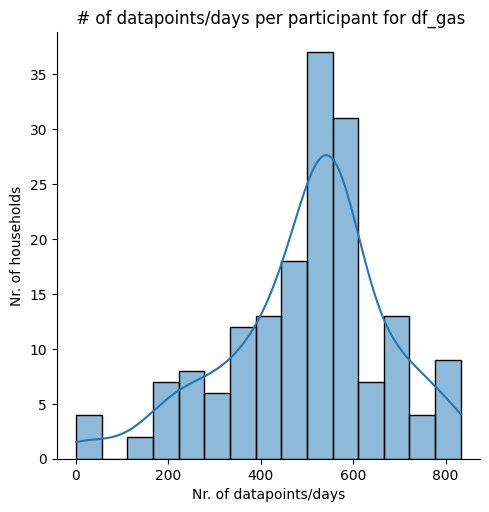

                time  gas_consumption
participant_id                       
-B51sQOp         383              383
-ORiFQC6         518              518
-uFUg8jU         664              664
0RQyG6WX         422              422
0XvCtU3v         661              661


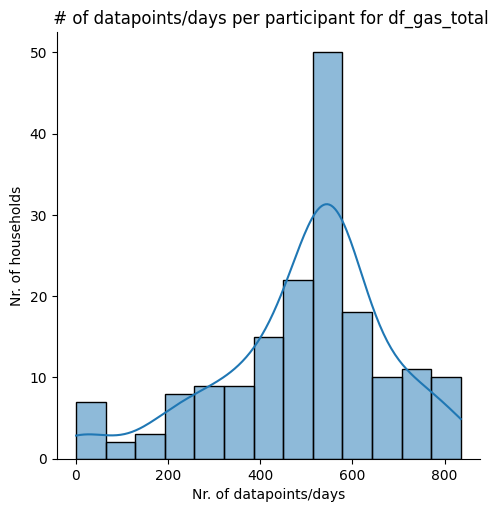

                time  gas_total
participant_id                 
Jr9PJjgK           1          1
gmtO-ZIa           1          1
ueGJf9d5           1          1
IF9c6c-H           4          4
uQLTOCT9           4          4


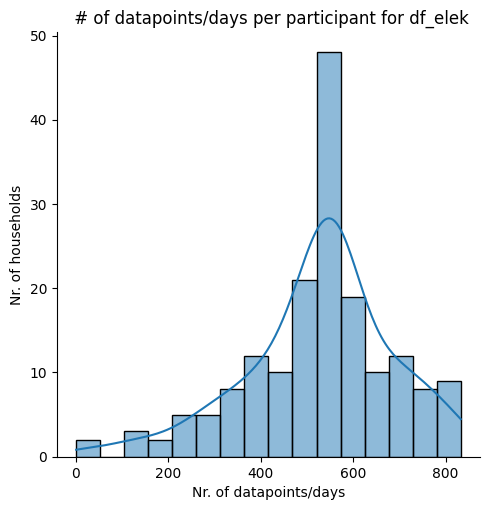

                time  elek_consumption
participant_id                        
-B51sQOp         385               385
-ORiFQC6         518               518
-uFUg8jU         664               664
0RQyG6WX         439               439
0XvCtU3v         661               661


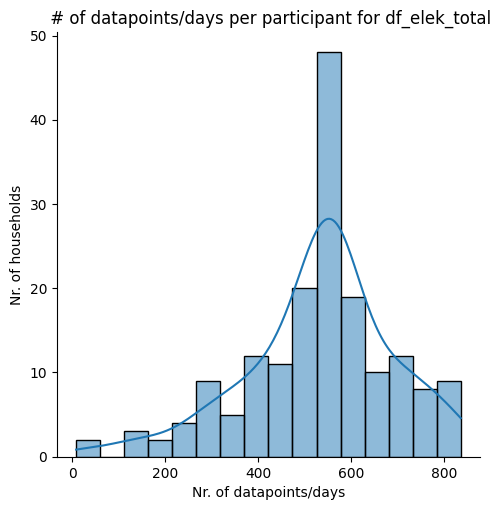

                time  electricity_total
participant_id                         
uQLTOCT9           8                  8
66lZ2dKl          34                 34
u3RHJ15y         120                120
KR2H1ovj         120                120
LzZTAYkZ         128                128


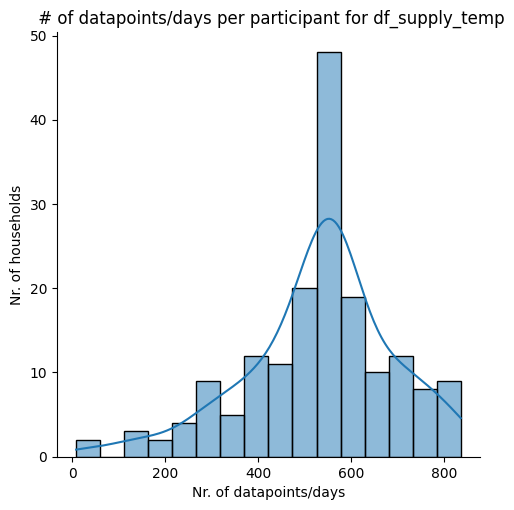

                time  supply_temp
participant_id                   
uQLTOCT9           8            8
66lZ2dKl          34           34
u3RHJ15y         120          120
KR2H1ovj         120          120
LzZTAYkZ         128          128


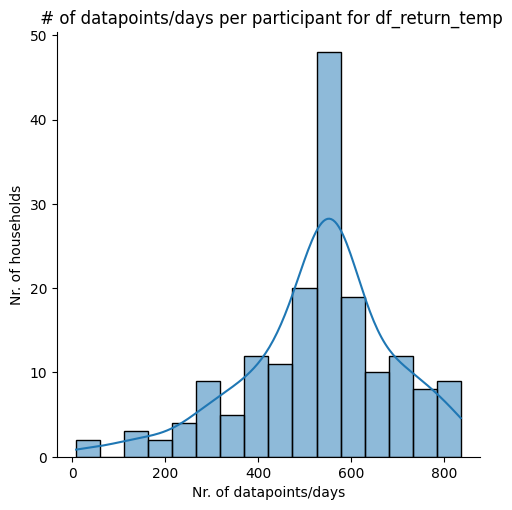

                time  return_temp
participant_id                   
uQLTOCT9           8            8
66lZ2dKl          34           34
u3RHJ15y         120          120
KR2H1ovj         120          120
LzZTAYkZ         128          128


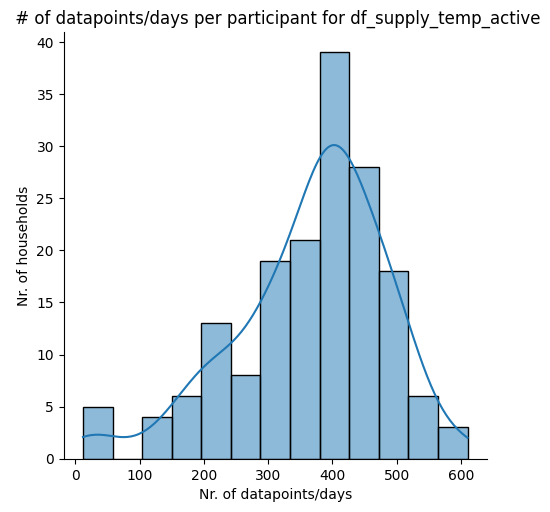

                time  supply_temp_active
participant_id                          
KR2H1ovj          12                  12
u3RHJ15y          26                  26
DlCdUGP1          29                  29
66lZ2dKl          33                  33
0XvCtU3v          34                  34


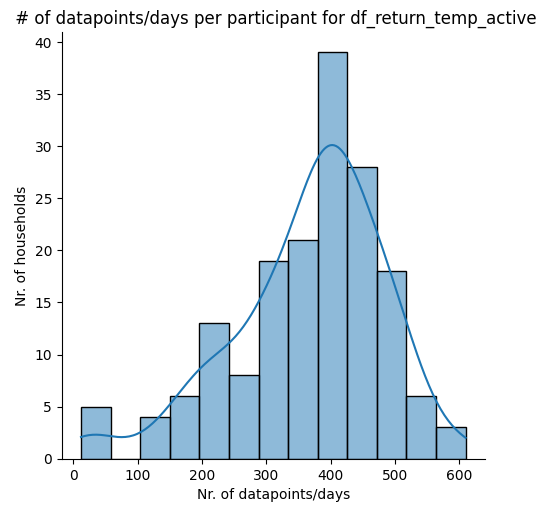

                time  return_temp_active
participant_id                          
KR2H1ovj          12                  12
u3RHJ15y          26                  26
DlCdUGP1          29                  29
66lZ2dKl          33                  33
0XvCtU3v          34                  34


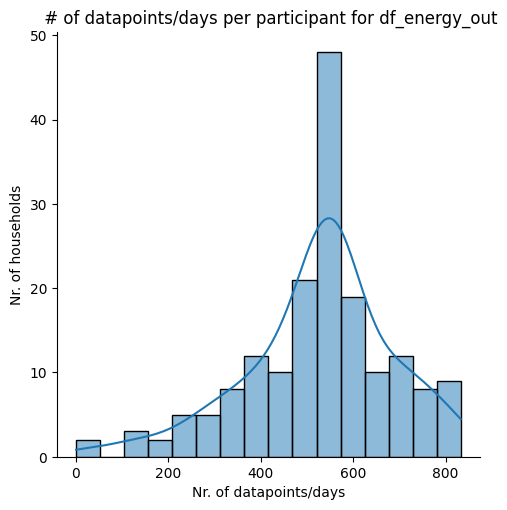

                time  energy_out
participant_id                  
-B51sQOp         385         385
-ORiFQC6         518         518
-uFUg8jU         664         664
0RQyG6WX         439         439
0XvCtU3v         661         661


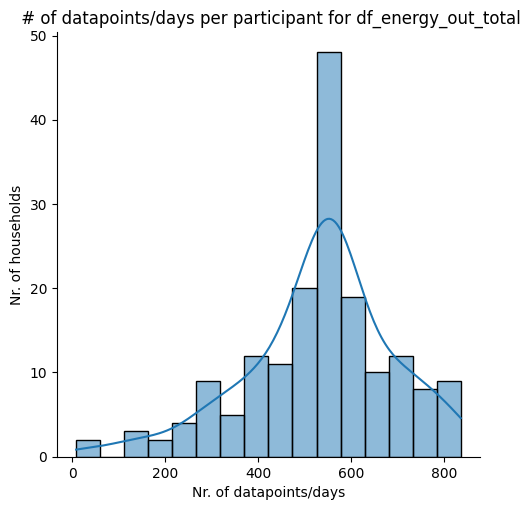

                time  energy_out_total
participant_id                        
uQLTOCT9           8                 8
66lZ2dKl          34                34
u3RHJ15y         120               120
KR2H1ovj         120               120
LzZTAYkZ         128               128


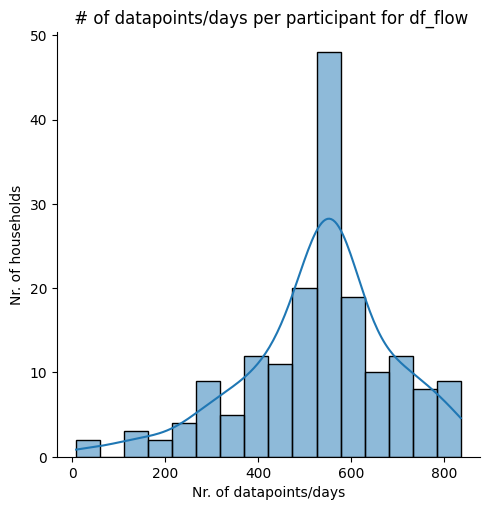

                time  flowrate
participant_id                
uQLTOCT9           8         8
66lZ2dKl          34        34
u3RHJ15y         120       120
KR2H1ovj         120       120
LzZTAYkZ         128       128


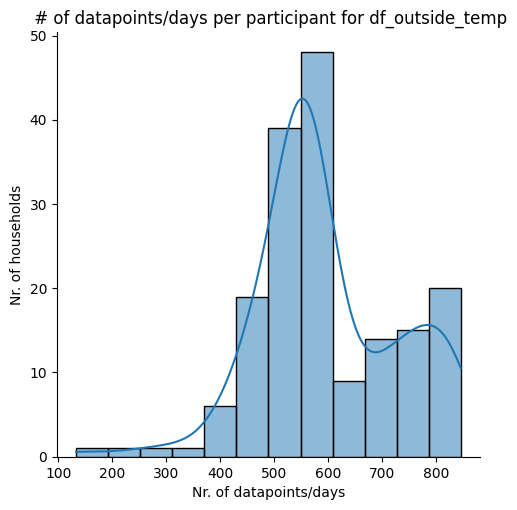

                time  outside_temp
participant_id                    
uQLTOCT9         133           133
JqpjoDDU         230           230
zskLB4tU         296           296
u3RHJ15y         319           319
D8ZSj9yG         384           384


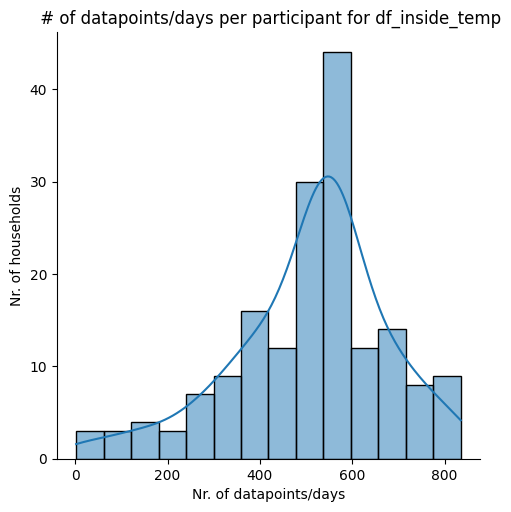

                time  inside_temp
participant_id                   
3jcFOgZ5           2            2
uQLTOCT9           4            4
66lZ2dKl          34           34
yNmVF4oy          63           63
u3RHJ15y         112          112


In [18]:
for df, df_name in df_list: 
    if df_name == "df_missing": continue 
    temp = df.groupby('participant_id').count().sort_values(by=df.columns[1])
    sns.displot(temp[temp.columns[1]],  kde=True)
    ax = plt.gca()
    plt.title(f" # of datapoints/days per participant for {df_name}")
    ax.set_ylabel('Nr. of households') 
    ax.set_xlabel('Nr. of datapoints/days') 
    plt.show()
    print(temp.head())